<a href="https://colab.research.google.com/github/vanessamutimaamba-stack/Practice_code/blob/main/ALY6040_Quiz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
#Load the dataset
df=pd.read_csv("Oscar_2000_2018.csv")
#Check the first few rows
print(df.head())


   year                                              movie   movie_id  \
0  2001                                     Kate & Leopold  tt0035423   
1  2000                                        Chicken Run  tt0120630   
2  2005                                     Fantastic Four  tt0120667   
3  2002                                              Frida  tt0120679   
4  2001  The Lord of the Rings: The Fellowship of the Ring  tt0120737   

  certificate  duration                       genre  rate  metascore  \
0       PG-13       118      Comedy|Fantasy|Romance   6.4       44.0   
1           G        84  Animation|Adventure|Comedy   7.0       88.0   
2       PG-13       106     Action|Adventure|Family   5.7       40.0   
3           R       123     Biography|Drama|Romance   7.4       61.0   
4       PG-13       178     Adventure|Drama|Fantasy   8.8       92.0   

                                            synopsis    votes  ...  \
0  An English Duke from 1876 is inadvertedly drag...    66

In [14]:
#Clean the data(drop rows either review count is missing )
df_clean=df.dropna(subset=['user_reviews','critic_reviews'])

In [15]:
display(df_clean.describe())

,year,duration,rate,metascore,votes,gross,user_reviews,critic_reviews,popularity,awards_wins,...,Boston_Society_of_Film_Critics_won,Boston_Society_of_Film_Critics_nominated,New_York_Film_Critics_Circle_won,New_York_Film_Critics_Circle_nominated,Los_Angeles_Film_Critics_Association_won,Los_Angeles_Film_Critics_Association_nominated,release_date.year,release_date.month,release_date.day-of-month,release_date.day-of-week
count,1220.000000,1220.000000,1220.000000,1197.000000,1.220000e+03,1.184000e+03,1220.000000,1220.000000,1100.000000,1220.000000,...,1220.000000,1220.000000,1220.000000,1220.000000,1220.000000,1220.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,2008.506557,115.577869,7.065246,64.132832,1.887749e+05,8.684313e+07,568.658197,266.716393,1270.490909,3.009836,...,0.170492,0.329508,0.150000,0.311475,0.186066,0.336885,2008.526316,6.770259,16.044277,4.693400
std,5.243610,21.283346,0.824117,16.995816,1.908266e+05,1.046407e+08,578.096891,145.824571,1026.061367,6.376348,...,0.594297,0.904613,0.518367,0.835845,0.579074,0.897787,5.129137,3.688070,8.310380,0.756509
min,2000.000000,8.000000,2.400000,9.000000,1.310000e+02,1.207000e+03,1.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2000.000000,1.000000,1.000000,1.000000
25%,2004.000000,101.000000,6.600000,52.000000,6.183375e+04,1.566000e+07,214.750000,161.750000,489.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2004.000000,3.000000,9.000000,5.000000
50%,2008.500000,114.000000,7.200000,66.000000,1.356040e+05,5.219300e+07,403.000000,238.000000,1063.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2008.000000,7.000000,16.000000,5.000000
75%,2013.000000,128.000000,7.600000,78.000000,2.603930e+05,1.200594e+08,708.250000,351.000000,1763.750000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2013.000000,10.000000,23.000000,5.000000
max,2018.000000,224.000000,9.000000,100.000000,1.743331e+06,9.366300e+08,5078.000000,816.000000,4937.000000,49.000000,...,5.000000,6.000000,5.000000,6.000000,5.000000,7.000000,2018.000000,12.000000,31.000000,7.000000


In [16]:
#Calculate Pearson's correlation coefficient (r)
r,p_value=pearsonr(df_clean['user_reviews'],df_clean['critic_reviews'])
print(f"The Pearson's correlation coefficient (r) is {r:.4f}")

The Pearson's correlation coefficient (r) is 0.4958


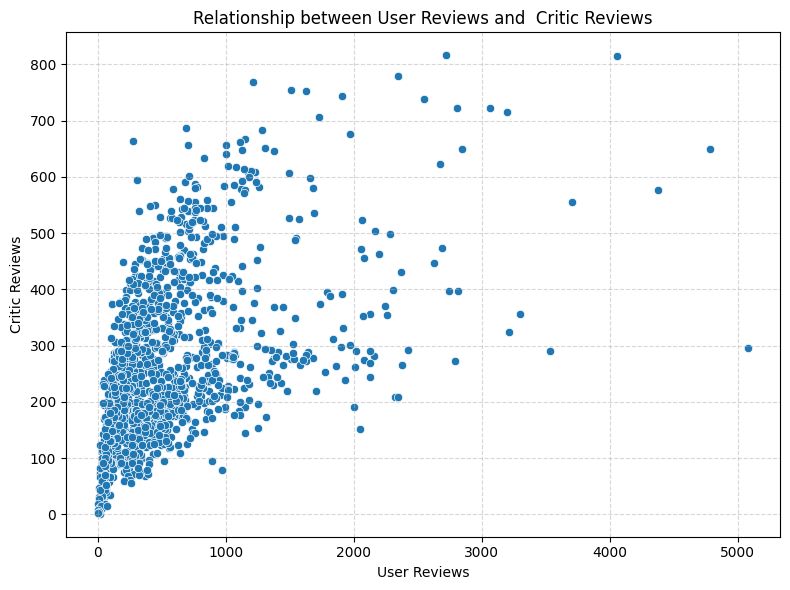

In [18]:
#Create a scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(x='user_reviews',y='critic_reviews',data=df_clean)
plt.title('Relationship between User Reviews and  Critic Reviews')
plt.xlabel('User Reviews')
plt.ylabel('Critic Reviews')
plt.grid(True,linestyle='--',alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipykernel_17373/3403924963.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='certificate',y='duration',data=average_duration,palette='viridis')


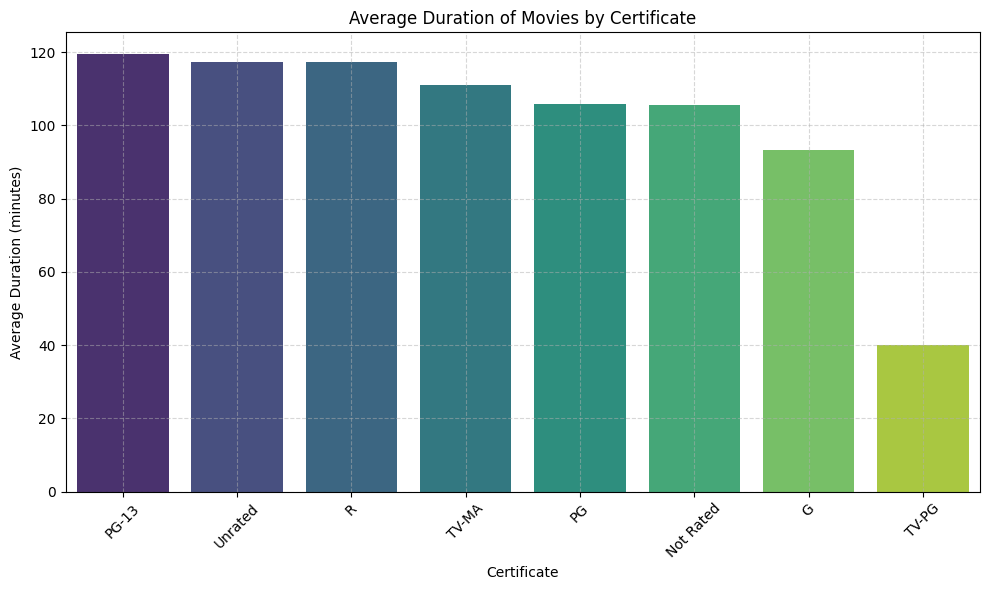

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#Calculate the average duration for each certificate
average_duration=df_clean.groupby('certificate')['duration'].mean().reset_index()
#Sort the values by duration for a cleaner plot
average_duration=average_duration.sort_values(by='duration',ascending=False)
#Create bar plot
plt.figure(figsize=(10,6))
sns.barplot(x='certificate',y='duration',data=average_duration,palette='viridis')
plt.title('Average Duration of Movies by Certificate')
plt.xlabel('Certificate')
plt.ylabel('Average Duration (minutes)')
plt.xticks(rotation=45)
plt.grid(True,linestyle='--',alpha=0.5)
plt.tight_layout()
plt.show()

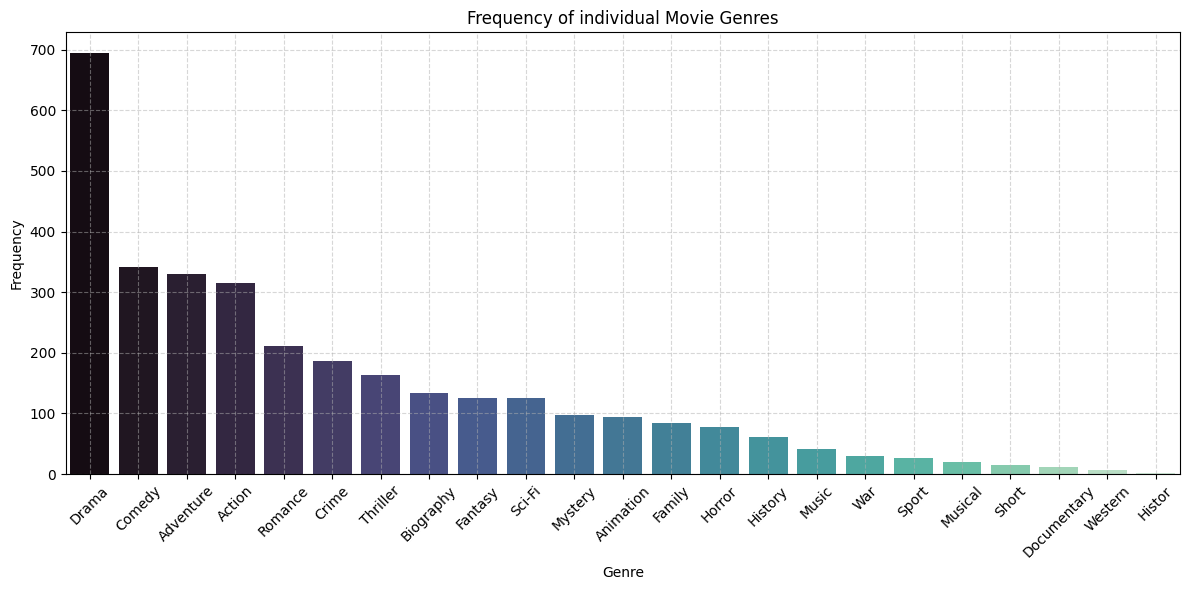

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
split_genres=df['genre'].dropna().str.split('|')
exploded_genres=split_genres.explode()
genre_counts=exploded_genres.value_counts().reset_index()
genre_counts.columns=['genre','count']
#Create a bar chart chart (histogram of categorical frequencies)
plt.figure(figsize=(12,6))
sns.barplot(x='genre',y='count',data=genre_counts,hue='genre',palette='mako',legend=False)
plt.title('Frequency of individual Movie Genres')
plt.xlabel('Genre')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(True,linestyle='--',alpha=0.5)
plt.tight_layout()
plt.show()

In [28]:
target='Oscar_Best_Picture_won' # Corrected to match the actual column name casing
column_to_drop=[col for col in df_clean.columns if col.startswith('Oscar_Best') and col.endswith('_won') and col!=target]
df_clean=df_clean.drop(columns=column_to_drop)
print(f'Dropped {len(column_to_drop)} columns')
print(f"The target variable '{target}' remains in the target dataset: {target in df_clean.columns}")

Dropped 0 columns
The target variable 'Oscar_Best_Picture_won' remains in the target dataset: False


In [34]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import shap
import matplotlib.pyplot as plt

# Re-create df_clean from the original df to ensure it's in a clean state,
# as previous operations might have inadvertently altered it.
# This assumes 'df' is correctly loaded from an earlier cell.
df_clean = df.dropna(subset=['user_reviews','critic_reviews']).copy()

target='Oscar_Best_Picture_won' # User's intended target name

# Check if 'Oscar_Best_Picture_won' column exists. If not, try to derive it.
if target not in df_clean.columns:
    # First, check for a casing mismatch (e.g., 'Oscar_Best_Picture_Won').
    if 'Oscar_Best_Picture_Won' in df_clean.columns:
        df_clean.rename(columns={'Oscar_Best_Picture_Won': target}, inplace=True)
        print(f"Renamed 'Oscar_Best_Picture_Won' to '{target}'.")
    # If not found, and 'Oscar_Best_Picture_nominated' exists, create 'Oscar_Best_Picture_won' from it.
    elif 'Oscar_Best_Picture_nominated' in df_clean.columns:
        # Assuming nomination implies a binary 'won' equivalent (1 if nominated, 0 if not).
        # For simplicity, if nominated has a non-zero value, treat as 1.
        df_clean[target] = df_clean['Oscar_Best_Picture_nominated'].apply(lambda x: 1 if x > 0 else 0)
        print(f"Created '{target}' from 'Oscar_Best_Picture_nominated' (1 if nominated, 0 otherwise).")
    else:
        # If neither specific won/nominated column is found, print a warning.
        print(f"Warning: Neither '{target}' nor 'Oscar_Best_Picture_Won' nor 'Oscar_Best_Picture_nominated' found in the DataFrame. Proceeding may result in errors.")

# At this point, the target column should exist, or a warning was issued.
if target not in df_clean.columns:
    # If it still doesn't exist after attempts to create/rename, the KeyError is still valid.
    # This explicit check will make the error message clearer if derivation failed.
    raise KeyError(f"The target column '{target}' is still not found in df_clean. Please ensure the raw data contains a suitable column or verify the logic to create it.")


# Drop other Oscar-related 'won' columns, but keep the target.
# This ensures only the chosen target 'won' column is retained.
column_to_drop_others=[col for col in df_clean.columns if col.startswith('Oscar_Best') and col.endswith('_won') and col!=target]
if column_to_drop_others:
    df_clean.drop(columns=column_to_drop_others, inplace=True)
    print(f'Dropped {len(column_to_drop_others)} other Oscar-related "won" columns (excluding target).')
else:
    print('No other Oscar-related "won" columns to drop (excluding target) or they were already removed.')


# Process the target variable: convert 'Yes'/'No' to 1/0 and ensure numeric type.
# Using .map() for cleaner string-to-numeric conversion to avoid FutureWarning from .replace()
df_clean[target] = df_clean[target].map({'Yes':1,'No':0})
df_clean[target] = pd.to_numeric(df_clean[target], errors='coerce')


threshold=0.70
cols_to_drop=[]

# Check for highly imbalanced classes in the target variable
# Using .iloc[0] to robustly get the first value from value_counts result.
most_frequent_ratio = df_clean[target].value_counts(normalize=True, dropna=False).iloc[0]
if most_frequent_ratio > threshold:
    cols_to_drop.append(target) # Corrected 'col' to 'target'
    print(f"Target variable '{target}' has a most frequent ratio of {most_frequent_ratio:.2f}, which is above the threshold of {threshold}. It will be considered for dropping if `cols_to_drop` is used later.")
else:
    print(f"Target variable '{target}' is not highly imbalanced (most frequent ratio: {most_frequent_ratio:.2f}).")

Dropped 7 other Oscar-related "won" columns (excluding target).
Target variable 'Oscar_Best_Picture_won' has a most frequent ratio of 0.99, which is above the threshold of 0.7. It will be considered for dropping if `cols_to_drop` is used later.


In [35]:
df_reduced=df_clean.drop(columns=cols_to_drop)
print(f'Dropped {len(cols_to_drop)} columns')

Dropped 1 columns


Maximum predicted probability:in the test data set of 2018 Movies 0.2400


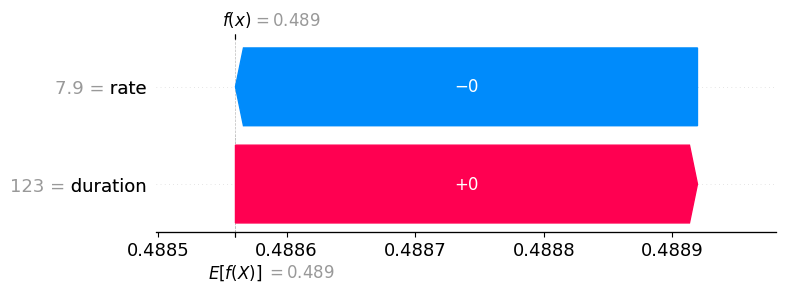

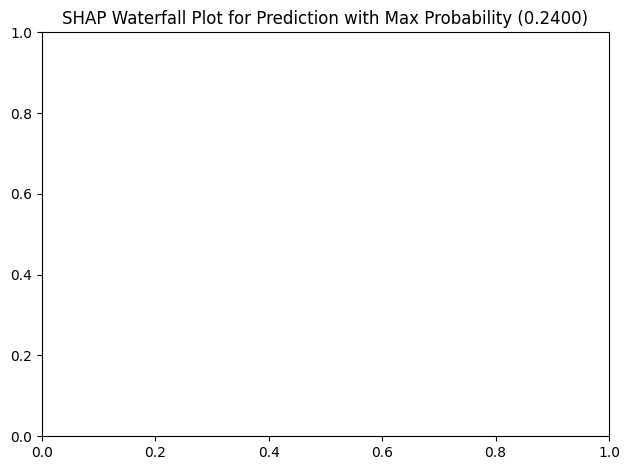

In [40]:
from matplotlib import figure
import numpy as np # Ensure numpy is imported
from sklearn.ensemble import RandomForestClassifier # Ensure RandomForestClassifier is imported
import shap # Ensure shap is imported
import matplotlib.pyplot as plt

df_numeric=df_reduced.select_dtypes(include=np.number)

# Define target as it might be dropped if highly imbalanced from df_reduced
# We need to re-introduce it for splitting and modeling if it was dropped
# Assuming target is 'Oscar_Best_Picture_won' as in previous cells
if 'Oscar_Best_Picture_won' not in df_numeric.columns and 'Oscar_Best_Picture_won' in df_clean.columns:
    df_numeric = pd.concat([df_numeric, df_clean['Oscar_Best_Picture_won']], axis=1)

train_data=df_numeric[df_numeric['year']<2017]
test_data=df_numeric[df_numeric['year']>=2017]

# Prepare features and target variables
X_train=train_data.drop(columns=[target,'year'],errors='ignore') # Fixed 'ignore' to be a string
y_train=train_data[target] # y_train was missing
X_test=test_data.drop(columns=[target,'year'],errors='ignore') # X_test was missing
y_test=test_data[target]

X_train=X_train.fillna(0)
X_test=X_test.fillna(0)

# Initialize and train the RandomForestClassifier with class_weight='balanced'
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred_probs=rf_model.predict_proba(X_test)[:,1]
max_pred_prob=y_pred_probs.max()
min_pred_prob=y_pred_probs.min()
print(f"Maximum predicted probability:in the test data set of 2018 Movies {max_pred_prob:.4f}")

explainer=shap.TreeExplainer(rf_model)

# Correctly find the index of the maximum predicted probability
max_pred_idx = np.argmax(y_pred_probs) # Fixed the syntax and defined max_pred_idx

shap_values=explainer.shap_values(X_test)

# Create a shap.Explanation object for the waterfall plot
# For binary classification, shap_values is a list of two arrays: [shap_values_for_class_0, shap_values_for_class_1]
# We want the explanation for the positive class (class 1)
shap_values_for_waterfall = shap.Explanation(
    values=shap_values[1][max_pred_idx],
    base_values=explainer.expected_value[1],
    data=X_test.iloc[max_pred_idx].values,
    feature_names=X_test.columns.tolist()
)

plt.figure(figsize=(10,6))
# Pass the Explanation object to the waterfall plot
shap.plots.waterfall(shap_values_for_waterfall)
plt.title(f"SHAP Waterfall Plot for Prediction with Max Probability ({max_pred_prob:.4f})")
plt.tight_layout()
plt.show()